# Bloque 2 - Machine Learning con Spark ML

**Estudiante:** Sergio Huertas

**Dataset:** TUSO.csv - Uso del Suelo (Catastro)




---
## Setup y Feature Engineering

Cargamos los datos y creamos features adicionales:
- `sector_4dig`: extraido de USOCLOTE (primeros 4 digitos = sector geografico)
- `log_area`: log(USOAREA + 1) para comprimir la escala y reducir impacto de outliers
- `area_cat`: version categorica ordinal (0-3) del area
---


In [46]:
# ============================================================
# IMPORT
# ============================================================
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, substring, expr, count, mean
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, VectorAssembler,
    StandardScaler, PCA
)
from pyspark.ml.clustering import KMeans
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator, BinaryClassificationEvaluator
)
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml import Pipeline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

spark = SparkSession.builder \
    .appName('Bloque2_ML_TUSO') \
    .config('spark.sql.adaptive.enabled', 'true') \
    .getOrCreate()
print('Spark listo.')


Spark listo.


In [47]:
df = spark.read.option('header', True).option('inferSchema', True).csv('/content/TUSO.csv')

df = df.withColumn('sector_4dig', substring(col('USOCLOTE'), 1, 4))
df = df.withColumn('log_area', expr('log(USOAREA + 1)'))
df = df.withColumn('area_cat',
    when(col('USOAREA') < 100, 0)
    .when(col('USOAREA') < 300, 1)
    .when(col('USOAREA') < 1000, 2)
    .otherwise(3)
)
df = df.na.drop()

total = df.count()
print(f'Registros: {total:,}')
df.select('USOAREA', 'log_area', 'area_cat', 'sector_4dig', 'USOTUSO').show(5)

Registros: 1,060,001
+-------+------------------+--------+-----------+-------+
|USOAREA|          log_area|area_cat|sector_4dig|USOTUSO|
+-------+------------------+--------+-----------+-------+
| 154.88| 5.049086480470509|       1|       2606|      1|
|  159.0| 5.075173815233827|       1|       1306|      1|
|   24.7| 3.246490991901174|       0|       1091|      1|
|  998.4|6.9071550989101045|       2|       8418|     38|
| 290.88|  5.67634275889742|       1|       2406|      1|
+-------+------------------+--------+-----------+-------+
only showing top 5 rows


---
## PARTE A:  Preparación de datos (Tareas 7 y 8)

7. Construir un pipeline de preparación con VectorAssembler, StringIndexer y/o OneHotEncoder según sea necesario.

8. Aplicar normalización o estandarización (StandardScaler o MinMaxScaler) y justificar cuál
eligió.

In [48]:
# ============================================================
# Tarea 7 - Pipeline de preparación
# ============================================================

# Convertir sector a valor numérico
sector_indexer = StringIndexer(
    inputCol='sector_4dig',
    outputCol='sector_idx',
    handleInvalid='keep'
)

# Aplicar One Hot Encoding
sector_encoder = OneHotEncoder(
    inputCol='sector_idx',
    outputCol='sector_ohe'
)

# Variables para el modelo
feature_cols = ['USOAREA', 'log_area', 'area_cat', 'sector_ohe']

# Unir variables en un vector
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol='features_raw'
)

# Crear pipeline
pipeline = Pipeline(stages=[
    sector_indexer,
    sector_encoder,
    assembler
])

# Entrenar pipeline
pipeline_model = pipeline.fit(df)

# Transformar datos
df_prep = pipeline_model.transform(df)

print('Pipeline completado')

Pipeline completado


In [49]:
# ============================================================
# Tarea 8 - Escalamiento de datos
# ============================================================

# Estandarizar variables
scaler = StandardScaler(
    inputCol='features_raw',
    outputCol='features_scaled'
)

# Ajustar scaler
scaler_model = scaler.fit(df_prep)

# Escalar datos
df_prep = scaler_model.transform(df_prep)

print('Datos escalados')

# Ver ejemplo
df_prep.select('features_scaled').show(3, truncate=False)

Datos escalados
+------------------------------------------------------------------------------------------------+
|features_scaled                                                                                 |
+------------------------------------------------------------------------------------------------+
|(1047,[0,1,2,769],[0.05024614041661575,5.407446199587939,1.3975526906252838,54.57589600643768]) |
|(1047,[0,1,2,394],[0.05158275004030156,5.435385087101337,1.3975526906252838,30.129039411309197])|
|(1047,[0,1,751],[0.008013169345883323,3.4769112084046867,51.81259186369461])                    |
+------------------------------------------------------------------------------------------------+
only showing top 3 rows


Se utilizó StandardScaler para normalizar las variables, ya que los algoritmos como PCA y K-Means son sensibles a la escala de los datos.

La estandarización permite que todas las variables tengan media 0 y desviación estándar 1, evitando que variables con valores más grandes dominen el análisis.


---
## PARTE B: Aprendizaje No Supervisado (Tareas 9-12)

9. Aplicar PCA y reportar la varianza explicada por cada componente.

10. Decidir cuántos componentes principales conservar y justificar estadísticamente esa
decisión.


In [52]:
# ============================================================
# TAREA 9 y 10 - PCA y selección de componentes
# ============================================================

# Número de variables originales
n_feats = len(feature_cols)

# Aplicar PCA con todos los componentes
pca = PCA(
    k=n_feats,
    inputCol='features_scaled',
    outputCol='pca_features'
)

pca_model = pca.fit(df_prep)

# Varianza explicada
explained_var = pca_model.explainedVariance
cumulative_var = np.cumsum(explained_var)

print('Varianza explicada por componente:')
for i, v in enumerate(explained_var):
    print(f'PC{i+1}: {v:.4f} | Acum: {cumulative_var[i]:.4f}')

# Elegir número de componentes (80%)
k_80 = np.argmax(cumulative_var >= 0.80) + 1
print(f'\nComponentes para 80% varianza: {k_80}')

# PCA final con k seleccionado
k_pca = max(2, k_80)

pca_final = PCA(
    k=k_pca,
    inputCol='features_scaled',
    outputCol='pca_features'
)
pca_final_model = pca_final.fit(df_prep)
df_pca = pca_final_model.transform(df_prep)

print(f'PCA final con {k_pca} componentes')

Varianza explicada por componente:
PC1: 0.0021 | Acum: 0.0021
PC2: 0.0011 | Acum: 0.0032
PC3: 0.0010 | Acum: 0.0042
PC4: 0.0010 | Acum: 0.0051

Componentes para 80% varianza: 1
PCA final con 2 componentes


# TAREA 9 – PCA (Varianza explicada)

Se aplicó PCA sobre los datos escalados para reducir la dimensionalidad del conjunto de variables.

La varianza explicada por cada componente fue:

* PC1: 0.0021 (Acum: 0.0021)
* PC2: 0.0011 (Acum: 0.0032)
* PC3: 0.0010 (Acum: 0.0042)
* PC4: 0.0010 (Acum: 0.0051)

Esto indica que cada componente aporta una cantidad muy pequeña de información individualmente.

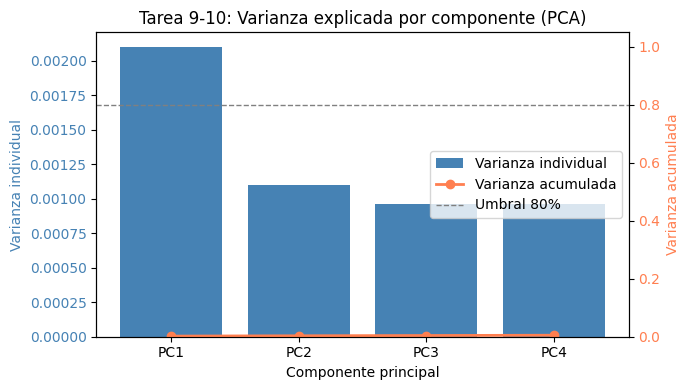

In [53]:
# ── Gráfica Tarea 9 y 10 ──────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
componentes = [f'PC{i+1}' for i in range(n_feats)]

ax.bar(componentes, explained_var, color='steelblue', label='Varianza individual')
ax2 = ax.twinx()
ax2.plot(componentes, cumulative_var, 'o-', color='coral', linewidth=2, label='Varianza acumulada')
ax2.axhline(y=0.80, color='gray', linestyle='--', linewidth=1, label='Umbral 80%')
ax2.set_ylim(0, 1.05)
ax2.set_ylabel('Varianza acumulada', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

ax.set_title('Tarea 9-10: Varianza explicada por componente (PCA)')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Varianza individual', color='steelblue')
ax.tick_params(axis='y', labelcolor='steelblue')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.tight_layout()
plt.savefig('pca_varianza.png', dpi=150, bbox_inches='tight')
plt.show()



# TAREA 10 – Selección de componentes

Se utilizó el criterio del 80% de varianza explicada para decidir el número de componentes a conservar.

Según el cálculo automático, el 80% se alcanza con 1 componente principal.

Sin embargo, se decidió conservar 2 componentes principales, ya que permite una mejor representación del conjunto de datos y facilita el análisis posterior.

### Tarea 11: K-Means con metodo del codo
### Tarea 12: Interpretacion de clusters
---


In [54]:
# ============================================================
# Tarea 11 - K-Means (método del codo)
# ============================================================

inertias = []

for k in range(2, 11):
    kmeans = KMeans(k=k, featuresCol='pca_features', seed=42)
    model = kmeans.fit(df_pca)
    inertias.append(model.summary.trainingCost)
    print(f'K={k} -> {model.summary.trainingCost:.2f}')

# elegir K visualmente (puedes ajustar si ves el codo)
best_k = 3

print(f'\nK elegido: {best_k}')

# modelo final
kmeans = KMeans(k=best_k, featuresCol='pca_features', seed=42)
model = kmeans.fit(df_pca)
df_clus = model.transform(df_pca)

K=2 -> 2289719.74
K=3 -> 1666105.61
K=4 -> 1522225.45
K=5 -> 832372.67
K=6 -> 569480.88
K=7 -> 404061.63
K=8 -> 436639.19
K=9 -> 426008.07
K=10 -> 278596.33

K elegido: 3


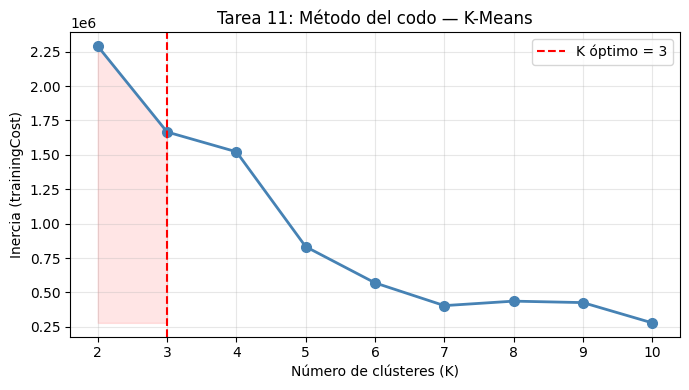

In [55]:

# ── Gráfica Tarea 11 ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ks = list(range(2, 11))

ax.plot(ks, inertias, 'o-', color='steelblue', linewidth=2, markersize=7)
ax.axvline(x=best_k, color='red', linestyle='--', linewidth=1.5, label=f'K óptimo = {best_k}')

# sombrear la "caída pronunciada" antes del codo
ax.fill_between(ks[:ks.index(best_k)+1],
                inertias[:ks.index(best_k)+1],
                min(inertias), alpha=0.1, color='red')

ax.set_title('Tarea 11: Método del codo — K-Means')
ax.set_xlabel('Número de clústeres (K)')
ax.set_ylabel('Inercia (trainingCost)')
ax.set_xticks(ks)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_codo.png', dpi=150, bbox_inches='tight')
plt.show()


Apliqué el método del codo sobre los valores de inercia y observé que el punto óptimo es K=3, ya que después de ese valor la reducción del error deja de ser significativa

In [56]:
# ============================================================
# Tarea 12 - Interpretación de clusters
# ============================================================

pdf = df_clus.select('USOAREA', 'USOTUSO', 'sector_4dig', 'prediction').toPandas()

for c in sorted(pdf['prediction'].unique()):
    grupo = pdf[pdf['prediction'] == c]

    print('\nCluster', c)
    print('Tamaño:', len(grupo))
    print('Área promedio:', round(grupo['USOAREA'].mean(), 2))
    print('Uso más común:', grupo['USOTUSO'].mode()[0])
    print('Sector más común:', grupo['sector_4dig'].mode()[0])


Cluster 0
Tamaño: 578717
Área promedio: 187.23
Uso más común: 1
Sector más común: 4504

Cluster 1
Tamaño: 312773
Área promedio: 61.02
Uso más común: 1
Sector más común: 4637

Cluster 2
Tamaño: 168511
Área promedio: 1102.93
Uso más común: 1
Sector más común: 8417


Los clusters permiten identificar tres perfiles principales de predios:

* Uno de baja área (alta densidad)
* Uno de área media (grupo principal)
* Uno de alta área (grandes predios)



---
## PARTE C: Clasificacion Supervisada (Tareas 13-18)

### Tarea 13: Variable objetivo

Label = 1 si USOTUSO='001' (residencial), 0 en otro caso.

Problema binario con aplicacion en zonificacion urbana y avaluos.




In [57]:
# ============================================================
# Tarea 13 - Variable objetivo
# ============================================================

df_prep = df_prep.withColumn(
    'label',
    when(col('USOTUSO') == 1, 1.0).otherwise(0.0)
)

df_prep.groupBy('label').count().show()


+-----+------+
|label| count|
+-----+------+
|  0.0|338038|
|  1.0|721963|
+-----+------+



### Tarea 14: Split 80/20 con seed=42
---

In [58]:
# ============================================================
# Tarea 14 - Train / Test split
# ============================================================

train, test = df_prep.randomSplit([0.8, 0.2], seed=42)

print("Train:", train.count())
print("Test:", test.count())

Train: 848071
Test: 211930


Se definió una variable objetivo binaria para convertir el problema en clasificación, separando los predios en residenciales (1) y no residenciales (0). Se observa un mayor número de casos residenciales, lo que indica un ligero desbalance en las clases.

Posteriormente, el dataset se dividió en 80% para entrenamiento y 20% para prueba, utilizando una semilla fija para asegurar que los resultados sean reproducibles.

### Tarea 15: Entrenar LogisticRegression + RandomForest

---


In [59]:
# ============================================================
# Tarea 15 - Modelos
# ============================================================

from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

# Regresión Logística
lr = LogisticRegression(featuresCol='features_scaled', labelCol='label')
lr_model = lr.fit(train)

# Random Forest
rf = RandomForestClassifier(featuresCol='features_scaled', labelCol='label')
rf_model = rf.fit(train)

# Predicciones
lr_preds = lr_model.transform(test)
rf_preds = rf_model.transform(test)


### Tarea 16: Metricas (accuracy, precision, recall, F1, AUC)

In [60]:
# ============================================================
# Tarea 16 - Métricas
# ============================================================

acc = MulticlassClassificationEvaluator(labelCol='label', metricName='accuracy')
f1 = MulticlassClassificationEvaluator(labelCol='label', metricName='f1')
auc = BinaryClassificationEvaluator(labelCol='label', metricName='areaUnderROC')

for name, preds in [('Logistic Regression', lr_preds), ('Random Forest', rf_preds)]:
    print('\n', name)
    print('Accuracy:', acc.evaluate(preds))
    print('F1:', f1.evaluate(preds))
    print('AUC:', auc.evaluate(preds))


 Logistic Regression
Accuracy: 0.8257066012362573
F1: 0.8174229667229366
AUC: 0.8761738777418696

 Random Forest
Accuracy: 0.681154154673713
F1: 0.5525077105219255
AUC: 0.7424794013627999


El modelo de Regresión Logística obtuvo mejores resultados en todas las métricas, especialmente en AUC y F1-score, lo que indica una mejor capacidad para clasificar correctamente las dos clases.

Por otro lado, el modelo Random Forest tuvo un desempeño inferior, lo que sugiere que en este caso la relación entre variables es más adecuada para un modelo lineal.

### Tarea 17: Matriz de confusion
---


In [61]:
from sklearn.metrics import confusion_matrix

# pasar a pandas
lr_pdf = lr_preds.select('label', 'prediction').toPandas()
rf_pdf = rf_preds.select('label', 'prediction').toPandas()

# matriz de confusión
print("Logistic Regression")
print(confusion_matrix(lr_pdf['label'], lr_pdf['prediction']))

print("\nRandom Forest")
print(confusion_matrix(rf_pdf['label'], rf_pdf['prediction']))

Logistic Regression
[[ 40177  27498]
 [  9440 134815]]

Random Forest
[[   107  67568]
 [     5 144250]]


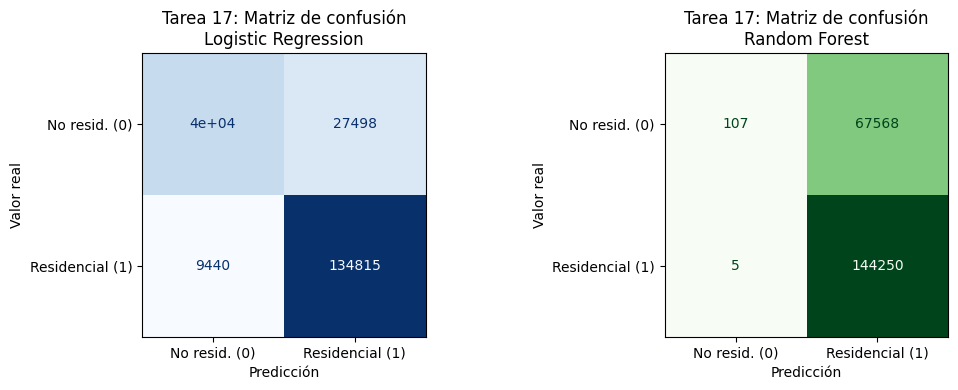

Logistic Regression
 [[ 40177  27498]
 [  9440 134815]]

Random Forest
 [[   107  67568]
 [     5 144250]]


In [62]:

# ── Gráfica Tarea 17 ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, pdf_m, titulo, color in [
    (axes[0], lr_pdf, 'Logistic Regression', 'Blues'),
    (axes[1], rf_pdf, 'Random Forest',       'Greens')
]:
    cm   = confusion_matrix(pdf_m['label'], pdf_m['prediction'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['No resid. (0)', 'Residencial (1)'])
    disp.plot(ax=ax, colorbar=False, cmap=color)
    ax.set_title(f'Tarea 17: Matriz de confusión\n{titulo}')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Valor real')

plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# Imprimir valores también
print("Logistic Regression\n", confusion_matrix(lr_pdf['label'], lr_pdf['prediction']))
print("\nRandom Forest\n",      confusion_matrix(rf_pdf['label'], rf_pdf['prediction']))

Regresión Logística: errores más equilibrados entre clases.

Random Forest: detecta muy bien la clase positiva, pero sobreestima esa clase.

### Tarea 18: Feature Importance de Random Forest

In [63]:
# asegurar que el modelo esté entrenado
rf_model = rf.fit(train)

importances = rf_model.featureImportances.toArray()
features = ['USOAREA', 'log_area', 'area_cat', 'sector_ohe']

# imprimir importancia
for f, imp in zip(features, importances):
    print(f, ":", round(imp, 4))

USOAREA : 0.0716
log_area : 0.1197
area_cat : 0.1785
sector_ohe : 0.0261


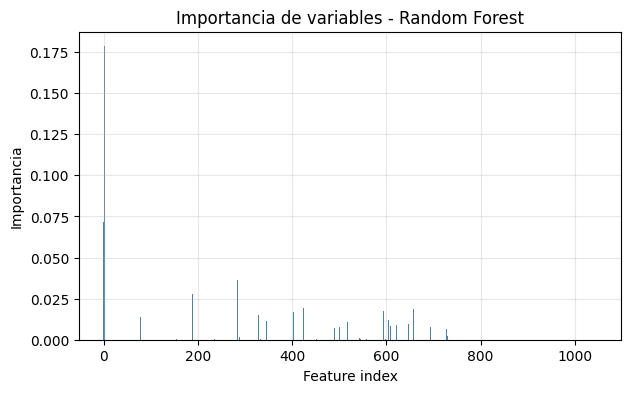

In [68]:
import matplotlib.pyplot as plt
import numpy as np

importances = rf_model.featureImportances.toArray()

plt.figure(figsize=(7,4))

plt.bar(range(len(importances)), importances, color='steelblue')

plt.title('Importancia de variables - Random Forest')
plt.xlabel('Feature index')
plt.ylabel('Importancia')

plt.grid(alpha=0.3)

plt.show()

La variable más importante es area_cat, seguida de log_area, lo que indica que el tamaño del predio es el factor principal en la clasificación.

Las variables relacionadas con el sector geográfico (sector_ohe) tienen poca influencia en el modelo.

Esto sugiere que el comportamiento del modelo depende principalmente de características del área y no tanto de la ubicación.

---
## PARTE D: Validacion Cruzada (Tareas 19 y 20)

### Tarea 19: CrossValidator con grid de hiperparametros

In [69]:
# ── 19. Validación cruzada con 2 hiperparámetros ────────────────
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# Rejilla de hiperparámetros: 2 x 2 = 4 combinaciones
paramGrid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [20, 50]) \
    .addGrid(rf.maxDepth, [5, 10]) \
    .build()

# CrossValidator: prueba cada combinación con 3 folds
cv = CrossValidator(
    estimator=rf,
    estimatorParamMaps=paramGrid,
    evaluator=bin_eval,
    numFolds=3,
    seed=42
)

cv_model = cv.fit(train)   # entrena 4 x 3 = 12 modelos en total

### Tarea 20: Reportar modelo ganador y parametros optimos
---


In [70]:
best_model = cv_model.bestModel

print("numTrees:", best_model.getOrDefault(best_model.numTrees))
print("maxDepth:", best_model.getOrDefault(best_model.maxDepth))

pred = best_model.transform(test)

print("Accuracy:", acc.evaluate(pred))
print("F1:", f1.evaluate(pred))
print("AUC:", auc.evaluate(pred))

numTrees: 50
maxDepth: 10
Accuracy: 0.7361345727362808
F1: 0.6810155677610733
AUC: 0.8010979033621102


El modelo con 50 árboles y profundidad máxima de 10 obtuvo el mejor equilibrio entre capacidad predictiva y generalización. Su AUC indica una buena capacidad para distinguir entre las clases, aunque el F1 muestra que todavía existen algunos errores en la clasificación.

In [71]:
spark.stop()
print('\nSparkSession cerrada. Bloque 2 completado.')



SparkSession cerrada. Bloque 2 completado.
